# 03 — LSTM Autoencoder Training
**VitalTracker**

In [1]:
import os
BASE_PATH      = r'C:\Users\Saqib\OneDrive\Desktop\VitalTracker'
PROCESSED_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODEL_PATH     = os.path.join(BASE_PATH, 'models', 'lstm_autoencoder')
os.makedirs(MODEL_PATH, exist_ok=True)
for f in ['X_train.npy', 'X_test.npy']:
    status = '✓' if os.path.exists(os.path.join(PROCESSED_PATH, f)) else '✗ MISSING — run 02 first'
    print(f'{f}: {status}')

X_train.npy: ✓
X_test.npy: ✓


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.config.set_visible_devices([], 'GPU')  # CPU only
print(f'TensorFlow {tf.__version__} — CPU mode')

np.random.seed(42)
tf.random.set_seed(42)

WINDOW_SIZE      = 60
N_FEATURES       = 2
LSTM_UNITS_1     = 64
LSTM_UNITS_2     = 32
DROPOUT_RATE     = 0.2
LEARNING_RATE    = 1e-3
BATCH_SIZE       = 64
MAX_EPOCHS       = 100
PATIENCE         = 10
VALIDATION_SPLIT = 0.1

TensorFlow 2.21.0 — CPU mode


In [4]:
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train.npy'))
X_test  = np.load(os.path.join(PROCESSED_PATH, 'X_test.npy'))
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (18116, 60, 2)
X_test  : (4118, 60, 2)


In [5]:
inputs  = Input(shape=(WINDOW_SIZE, N_FEATURES))
x = LSTM(LSTM_UNITS_1, return_sequences=True)(inputs)
x = Dropout(DROPOUT_RATE)(x)
x = LSTM(LSTM_UNITS_2, return_sequences=False)(x)
x = Dropout(DROPOUT_RATE)(x)
x = RepeatVector(WINDOW_SIZE)(x)
x = LSTM(LSTM_UNITS_2, return_sequences=True)(x)
x = Dropout(DROPOUT_RATE)(x)
x = LSTM(LSTM_UNITS_1, return_sequences=True)(x)
x = Dropout(DROPOUT_RATE)(x)
outputs = TimeDistributed(Dense(N_FEATURES, activation='sigmoid'))(x)

model = Model(inputs, outputs, name='lstm_autoencoder')
model.compile(optimizer=Adam(LEARNING_RATE), loss='mse', metrics=['mae'])
model.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,850 (245.51 KB)

 Trainable params: 62,850 (245.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
checkpoint_path = os.path.join(MODEL_PATH, 'best_model.keras')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss',
                    save_best_only=True, verbose=1)
]
print(f'Training on {X_train.shape[0]:,} windows — expect 20-40 mins on CPU...')
history = model.fit(
    X_train, X_train,
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks, shuffle=True, verbose=1
)
print(f'Done. Epochs: {len(history.history["loss"])} | Best val_loss: {min(history.history["val_loss"]):.6f}')

Training on 18,116 windows — expect 20-40 mins on CPU...
Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0186 - mae: 0.0928
Epoch 1: val_loss improved from None to 0.00266, saving model to C:\Users\Saqib\OneDrive\Desktop\VitalTracker\models\lstm_autoencoder\best_model.keras

Epoch 1: finished saving model to C:\Users\Saqib\OneDrive\Desktop\VitalTracker\models\lstm_autoencoder\best_model.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - loss: 0.0085 - mae: 0.0602 - val_loss: 0.0027 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0021 - mae: 0.0331
Epoch 2: val_loss improved from 0.00266 to 0.00205, saving model to C:\Users\Saqib\OneDrive\Desktop\VitalTracker\models\lstm_autoencoder\best_model.keras

Epoch 2: finished saving model to C:\Users\Saqib\OneDrive\Desktop\VitalTracker\models\lstm_autoencoder\best_model.keras
255/255 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - loss: 0.0020 - mae: 0.0317 - val_loss: 0.0021 - va

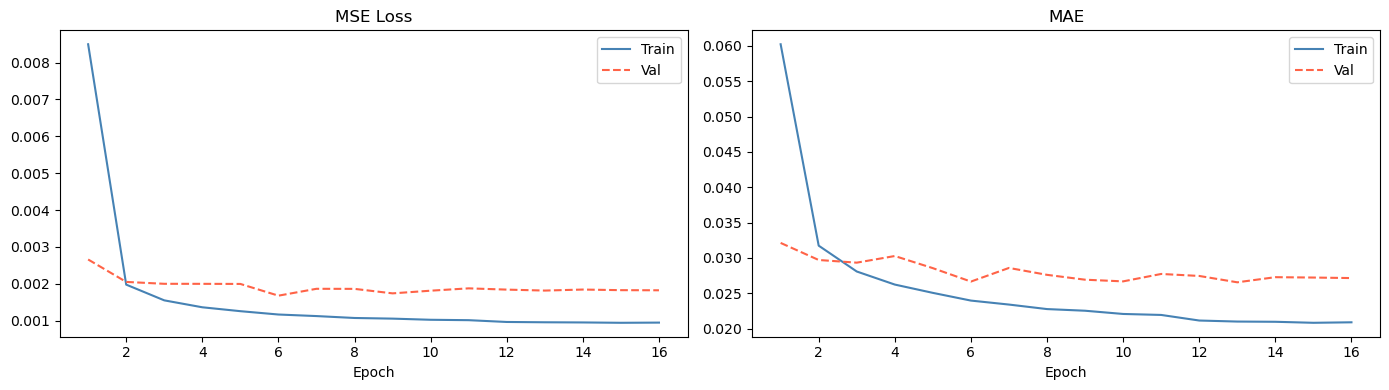

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e = range(1, len(history.history['loss']) + 1)
axes[0].plot(e, history.history['loss'],     color='steelblue', label='Train')
axes[0].plot(e, history.history['val_loss'], color='tomato',    label='Val', linestyle='--')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(e, history.history['mae'],     color='steelblue', label='Train')
axes[1].plot(e, history.history['val_mae'], color='tomato',    label='Val', linestyle='--')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'training_curves.png'), dpi=150)
plt.show()

284/284 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Train — mean: 0.000857 | p95: 0.002774 | p99: 0.006123


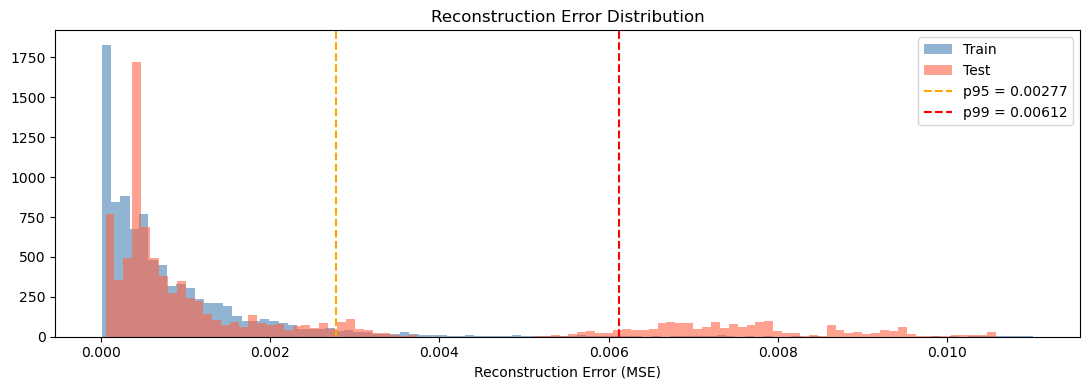

In [8]:
X_train_pred = model.predict(X_train, batch_size=BATCH_SIZE, verbose=1)
X_test_pred  = model.predict(X_test,  batch_size=BATCH_SIZE, verbose=1)
train_errors = np.mean(np.square(X_train - X_train_pred), axis=(1, 2))
test_errors  = np.mean(np.square(X_test  - X_test_pred),  axis=(1, 2))
p95 = float(np.percentile(train_errors, 95))
p99 = float(np.percentile(train_errors, 99))
print(f'Train — mean: {train_errors.mean():.6f} | p95: {p95:.6f} | p99: {p99:.6f}')
np.save(os.path.join(PROCESSED_PATH, 'train_errors.npy'), train_errors)
np.save(os.path.join(PROCESSED_PATH, 'test_errors.npy'),  test_errors)

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(train_errors, bins=100, alpha=0.6, color='steelblue', label='Train', density=True)
ax.hist(test_errors,  bins=100, alpha=0.6, color='tomato',    label='Test',  density=True)
ax.axvline(p95, color='orange', linestyle='--', label=f'p95 = {p95:.5f}')
ax.axvline(p99, color='red',    linestyle='--', label=f'p99 = {p99:.5f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_title('Reconstruction Error Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
model.save(os.path.join(MODEL_PATH, 'model.keras'))
config_path = os.path.join(MODEL_PATH, 'config.json')
config = json.load(open(config_path)) if os.path.exists(config_path) else {}
config.update({
    'model_architecture': 'LSTM Autoencoder',
    'input_shape'       : [WINDOW_SIZE, N_FEATURES],
    'lstm_units'        : [LSTM_UNITS_1, LSTM_UNITS_2],
    'epochs_trained'    : len(history.history['loss']),
    'best_val_loss'     : float(min(history.history['val_loss'])),
    'train_error_stats' : {'p95': p95, 'p99': p99,
                           'mean': float(train_errors.mean()),
                           'std':  float(train_errors.std())}
})
json.dump(config, open(config_path, 'w'), indent=2)
print('=' * 40)
print('  DONE')
print(f'  Epochs    : {len(history.history["loss"])}')
print(f'  Val loss  : {min(history.history["val_loss"]):.6f}')
print(f'  p95       : {p95:.6f}')
print(f'  p99       : {p99:.6f}')
print(f'  Saved to  : {MODEL_PATH}')

  DONE
  Epochs    : 16
  Val loss  : 0.001679
  p95       : 0.002774
  p99       : 0.006123
  Saved to  : C:\Users\Saqib\OneDrive\Desktop\VitalTracker\models\lstm_autoencoder
